# Structural and Cross-Instrument Features

**Chapter 8: Feature Engineering**
**Section Reference**: 8.3 - Structural and Cross-Instrument Features
**Docker image**: `ml4t`

## Purpose

This notebook demonstrates features that require **data beyond a single asset's
price series**: term structures, cross-instrument relationships, and
derivatives-implied quantities. These encode information invisible in any
individual price history.

## Learning Objectives

1. Compute carry (roll yield) from futures term structure data
2. Build cross-asset beta and lead-lag correlation features
3. Extract options-implied features: ATM IV, risk reversal, IV term structure, VRP
4. Understand surface stability requirements for options features

## Feature Families Covered

| Family | Representative Features | Data Source |
|--------|------------------------|-------------|
| **Carry & Term Structure** | Roll yield, curve slope/curvature | CME futures |
| **Cross-Asset Structure** | Rolling beta, lead-lag, relative value | ETFs |
| **Options-Implied** | ATM IV, risk reversal, VRP, term slope | S&P 500 options |

## Data Policy

All examples use **real data**: CME futures, ETFs, and S&P 500 options.

In [1]:
"""Structural and Cross-Instrument Features — carry, cross-asset, and options-implied feature families."""

from __future__ import annotations

import warnings
from datetime import datetime
from typing import cast

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.paths import get_chapter_dir

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
FUTURES_START_DATE = ""
ETF_START_DATE = ""
OPT_SYMBOLS = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "BA", "XOM", "KO"]
OPTIONS_START_DATE = "2019-01-01"

In [3]:
def ensure_df(df: pl.DataFrame | pl.LazyFrame) -> pl.DataFrame:
    """Normalize loader outputs to eager DataFrames for notebook use."""
    return cast(pl.DataFrame, df.collect() if isinstance(df, pl.LazyFrame) else df)

---

# Part 1: Carry and Term Structure

Carry features encode **risk compensation**: the return from holding a position
absent price change. Roll yield from futures is the canonical example.

Key formula:

$$\text{carry}_{t,c} = \frac{F_{t,c}^{\text{near}} - F_{t,c}^{\text{far}}}{F_{t,c}^{\text{near}}} \times \frac{365}{\Delta T}$$

- Positive carry (backwardation): near > far — earn by holding
- Negative carry (contango): near < far — pay to hold

## 1.1 Load Futures Data

In [4]:
from data import load_cme_futures

# Focus on 4 liquid products spanning asset classes
PRODUCTS = ["ES", "CL", "GC", "ZN"]

futures = ensure_df(load_cme_futures(products=PRODUCTS, tenors=[0, 1, 2]))

if FUTURES_START_DATE:
    futures = futures.filter(
        pl.col("session_date") >= datetime.strptime(FUTURES_START_DATE, "%Y-%m-%d")
    )

print(f"Futures: {len(futures):,} rows")
print(f"Products: {futures['product'].unique().to_list()}")
print(f"Tenors: {futures['tenor'].unique().sort().to_list()}")
print(f"Date range: {futures['session_date'].min()} to {futures['session_date'].max()}")

Futures: 42,960 rows
Products: ['ES', 'GC', 'ZN', 'CL']
Tenors: [0, 1, 2]
Date range: 2011-01-03 to 2025-12-31


## 1.2 Roll Yield (Manual Implementation)

Roll yield is the annualized price difference between near and far contracts.
We pivot tenors to compute the spread.

In [5]:
def compute_roll_yield(df: pl.DataFrame) -> pl.DataFrame:
    """
    Compute annualized roll yield from tenor 0 (front) and tenor 1 (deferred).

    Roll yield = (F_near - F_far) / F_near * (365 / DeltaT)

    We approximate DeltaT ≈ 30 days (typical monthly roll).
    """
    # Pivot to get front and deferred prices side by side
    front = df.filter(pl.col("tenor") == 0).select(
        ["session_date", "product", pl.col("close").alias("close_front")]
    )
    deferred = df.filter(pl.col("tenor") == 1).select(
        ["session_date", "product", pl.col("close").alias("close_deferred")]
    )

    # Join and compute carry
    carry = front.join(deferred, on=["session_date", "product"], how="inner")
    carry = carry.with_columns(
        [
            # Raw roll yield
            ((pl.col("close_front") - pl.col("close_deferred")) / pl.col("close_front")).alias(
                "roll_yield_raw"
            ),
            # Annualized (assuming ~30 day roll period)
            (
                (pl.col("close_front") - pl.col("close_deferred"))
                / pl.col("close_front")
                * (365 / 30)
            ).alias("roll_yield_ann"),
        ]
    )

    return carry.sort(["product", "session_date"])


carry_df = compute_roll_yield(futures)

print("Roll yield (last rows per product):")
for product in PRODUCTS:
    row = carry_df.filter(pl.col("product") == product).tail(1)
    if len(row) > 0:
        ry = row["roll_yield_ann"][0]
        print(f"  {product}: {ry:+.4f} ({'backwardation' if ry > 0 else 'contango'})")

Roll yield (last rows per product):
  ES: -0.0885 (contango)
  CL: +0.0420 (backwardation)
  GC: -0.0909 (contango)
  ZN: +0.0084 (backwardation)


## 1.3 Term Structure Slope and Curvature

With three tenors we can also extract slope and curvature:

- **Slope**: $(F_0 - F_2) / F_0$ — overall term structure direction
- **Curvature**: $F_0 - 2 \cdot F_1 + F_2$ — butterfly shape

In [6]:
def compute_term_structure_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute slope and curvature from 3-tenor term structure."""
    t0 = df.filter(pl.col("tenor") == 0).select(
        ["session_date", "product", pl.col("close").alias("c0")]
    )
    t1 = df.filter(pl.col("tenor") == 1).select(
        ["session_date", "product", pl.col("close").alias("c1")]
    )
    t2 = df.filter(pl.col("tenor") == 2).select(
        ["session_date", "product", pl.col("close").alias("c2")]
    )

    ts = t0.join(t1, on=["session_date", "product"], how="inner").join(
        t2, on=["session_date", "product"], how="inner"
    )

    return ts.with_columns(
        [
            # Slope: normalized front-back spread
            ((pl.col("c0") - pl.col("c2")) / pl.col("c0")).alias("ts_slope"),
            # Curvature: butterfly (positive = humped)
            (pl.col("c0") - 2 * pl.col("c1") + pl.col("c2")).alias("ts_curvature"),
        ]
    )


ts_df = compute_term_structure_features(futures)

print("\nTerm structure features:")
ts_df.select(["session_date", "product", "ts_slope", "ts_curvature"]).tail(8)


Term structure features:


session_date,product,ts_slope,ts_curvature
date,str,f64,f64
2025-12-09,"""ZN""",0.000418,0.479769
2025-12-10,"""ZN""",-0.000278,0.653705
2025-12-11,"""ZN""",0.000139,0.326428
2025-12-12,"""ZN""",0.000835,0.465477
2025-12-15,"""ZN""",0.001113,0.466205
2025-12-16,"""ZN""",0.003055,0.186652
2025-12-18,"""ZN""",0.000693,0.422602
2025-12-19,"""ZN""",0.000695,0.171875


## 1.4 Visualize Carry Across Products

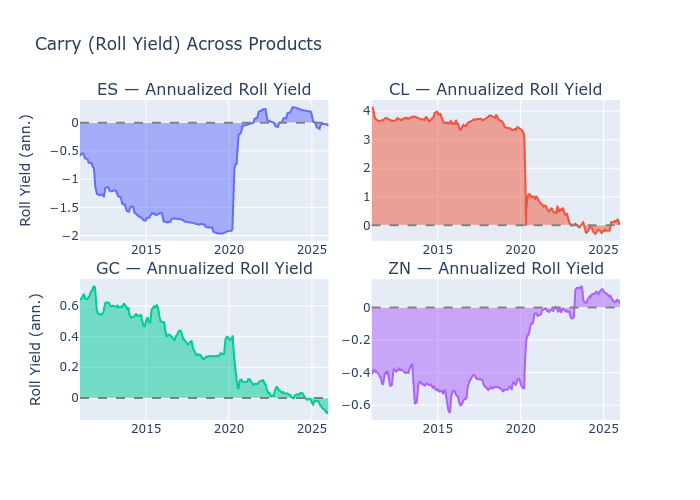

In [7]:
# Smooth carry with 21-day EMA for visualization
carry_smooth = carry_df.sort(["product", "session_date"]).with_columns(
    pl.col("roll_yield_ann")
    .ewm_mean(span=21, ignore_nulls=True)
    .over("product")
    .alias("carry_ema21")
)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f"{p} — Annualized Roll Yield" for p in PRODUCTS],
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)

for idx, product in enumerate(PRODUCTS):
    row, col = idx // 2 + 1, idx % 2 + 1
    subset = carry_smooth.filter(pl.col("product") == product)
    fig.add_trace(
        go.Scatter(
            x=subset["session_date"].to_list(),
            y=subset["carry_ema21"].to_list(),
            name=product,
            fill="tozeroy",
        ),
        row=row,
        col=col,
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray", row=row, col=col)

fig.update_layout(height=500, title="Carry (Roll Yield) Across Products", showlegend=False)
fig.update_yaxes(title_text="Roll Yield (ann.)", row=1, col=1)
fig.update_yaxes(title_text="Roll Yield (ann.)", row=2, col=1)
fig.show()

**Interpretation**: Backwardation (positive carry) in commodities like CL
typically indicates supply tightness. GC and ZN often trade in contango.
ES carry reflects the cost-of-carry relationship (dividends minus financing).

**Crypto funding rates** operate on a distinct clock (8-hour settlements) with
much higher volatility. See the `crypto_perps_funding` case study for the
full treatment.

**Full pipeline**: The `cme_futures` case study applies these features to all
30 CME products with proper roll handling and cross-sectional ranks.

### Book Figure: Cross-Sectional Roll Yield Snapshot

Load all CME products and plot a single-date snapshot of annualized roll yield
sorted by magnitude — the canonical carry signal from §8.3.

In [8]:
import matplotlib.pyplot as plt

# Load all products for the cross-section
all_futures = ensure_df(load_cme_futures(tenors=[0, 1]))

# Compute roll yield for all products
all_carry = compute_roll_yield(all_futures)

# Pick a representative date with good coverage (latest date with most products)
date_counts = all_carry.group_by("session_date").len().sort("len", descending=True)
len_max = date_counts["len"].max() if len(date_counts) > 0 else 0
max_products = len_max if isinstance(len_max, int) else 0
min_products = min(15, max_products) if max_products > 0 else 1
snapshot_date = date_counts.filter(pl.col("len") >= min_products)["session_date"].max()

snapshot = (
    all_carry.filter(pl.col("session_date") == snapshot_date)
    .select(["product", "roll_yield_ann"])
    .drop_nulls()
    .sort("roll_yield_ann")
)

print(f"Snapshot date: {snapshot_date}")
print(f"Products: {len(snapshot)}")

Snapshot date: 2025-12-30
Products: 29


In [9]:
# Sector mapping for fill patterns
SECTORS = {
    "CL": "Energy",
    "HO": "Energy",
    "NG": "Energy",
    "RB": "Energy",
    "GC": "Gold/Silver",
    "SI": "Gold/Silver",
    "HG": "Metals",
    "PA": "Metals",
    "PL": "Metals",
    "ZC": "Agriculture",
    "ZS": "Agriculture",
    "ZW": "Agriculture",
    "ZM": "Agriculture",
    "ZL": "Agriculture",
    "KC": "Agriculture",
    "CT": "Agriculture",
    "SB": "Agriculture",
    "CC": "Agriculture",
    "LC": "Agriculture",
    "LH": "Agriculture",
    "FC": "Agriculture",
    "ES": "Financials",
    "NQ": "Financials",
    "YM": "Financials",
    "RTY": "Financials",
    "ZN": "Rates",
    "ZB": "Rates",
    "ZF": "Rates",
    "ZT": "Rates",
    "GE": "Rates",
    "6E": "FX",
    "6J": "FX",
    "6B": "FX",
    "6A": "FX",
    "6C": "FX",
    "6S": "FX",
}
SECTOR_GRAYS = {
    "Energy": "0.15",
    "Gold/Silver": "0.30",
    "Metals": "0.40",
    "Agriculture": "0.55",
    "Financials": "0.70",
    "Rates": "0.80",
    "FX": "0.90",
}

Text(0.0, 1.0, 'Annualized Roll Yield Across CME Products (2025-12-30)')

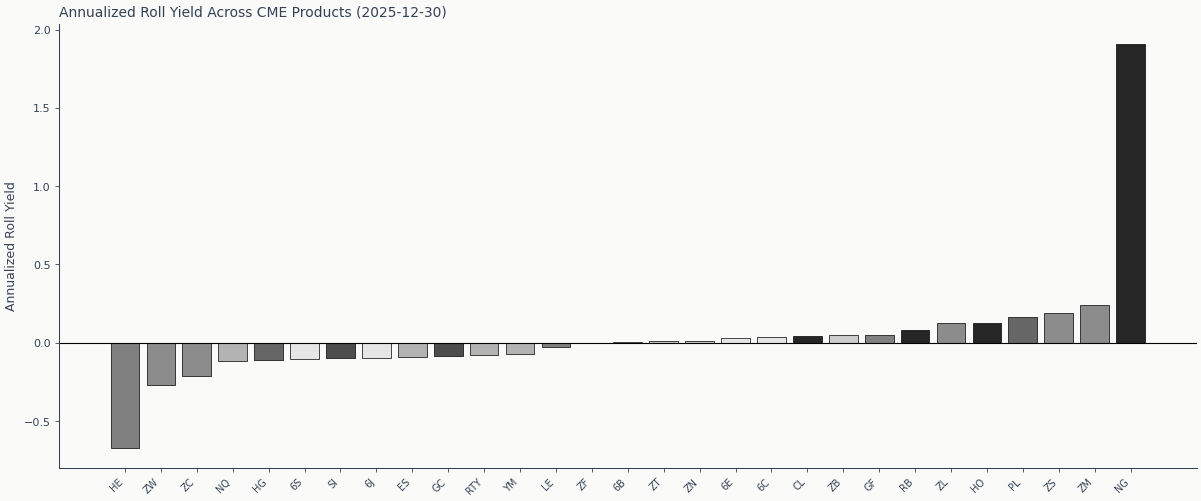

In [10]:
# Plot cross-sectional roll yield snapshot
products = snapshot["product"].to_list()
yields = snapshot["roll_yield_ann"].to_list()
colors = [SECTOR_GRAYS.get(SECTORS.get(p, "Other"), "0.50") for p in products]

fig_mpl, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(range(len(products)), yields, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(products)))
ax.set_xticklabels(products, fontsize=7, rotation=45, ha="right")
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_ylabel("Annualized Roll Yield")
ax.set_title(f"Annualized Roll Yield Across CME Products ({snapshot_date})")

In [11]:
# Annotations and legend
y_max, y_min = (max(yields), min(yields)) if yields else (0.1, -0.1)
ax.text(
    len(products) * 0.75,
    y_max * 0.7,
    "Backwardation\n(holder earns)",
    ha="center",
    va="center",
    fontsize=8,
    style="italic",
    color="0.3",
)
ax.text(
    len(products) * 0.25,
    y_min * 0.7,
    "Contango\n(holder pays)",
    ha="center",
    va="center",
    fontsize=8,
    style="italic",
    color="0.3",
)

# Compact sector legend
unique_sectors = sorted(set(SECTORS.get(p, "Other") for p in products))
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=SECTOR_GRAYS.get(s, "0.50"), ec="black", lw=0.5)
    for s in unique_sectors
]
ax.legend(
    legend_handles,
    unique_sectors,
    loc="upper left",
    fontsize=7,
    frameon=False,
    ncol=len(unique_sectors),
)

plt.show()

# Persist source data so book/08_financial_features/figures/scripts/generate_figure_8_4_*.py
# can re-render at print resolution without re-executing this notebook (Hard Rule 15).
_FIG_8_4_ARTIFACT = (
    get_chapter_dir(8) / "output" / "book_figure_artifacts" / "figure_8_4_carry_roll_yield.parquet"
)
_FIG_8_4_ARTIFACT.parent.mkdir(parents=True, exist_ok=True)
snapshot.with_columns(pl.lit(snapshot_date).alias("snapshot_date")).write_parquet(_FIG_8_4_ARTIFACT)

---

# Part 2: Cross-Asset Structure and Relative Value

Cross-asset features model relationships *between* instruments:
- **Rolling beta**: Sensitivity to a common factor (market, sector)
- **Lead-lag**: Temporal structure across markets
- **Relative value**: Deviation from peer mean (z-scored)

## 2.1 Load ETF Data

In [12]:
from data import load_etfs

etfs = load_etfs().sort(["symbol", "timestamp"])

if ETF_START_DATE:
    etfs = etfs.filter(pl.col("timestamp") >= datetime.strptime(ETF_START_DATE, "%Y-%m-%d"))

# Use a subset for cross-asset analysis: market + sectors + bonds + gold
CA_SYMBOLS = ["SPY", "QQQ", "XLF", "XLE", "XLK", "XLV", "TLT", "GLD"]
ca_etfs = etfs.filter(pl.col("symbol").is_in(CA_SYMBOLS)).sort(["symbol", "timestamp"])

print(f"Cross-asset universe: {ca_etfs['symbol'].n_unique()} assets, {len(ca_etfs):,} rows")

Cross-asset universe: 8 assets, 40,248 rows


## 2.2 Rolling Beta to Market

Rolling beta measures time-varying sensitivity to the market factor:

$$\beta_{t,a} = \frac{\text{Cov}(r_a, r_m)_t}{\text{Var}(r_m)_t}$$

In [13]:
from ml4t.engineer.features.cross_asset import beta_to_market

# Compute returns
ca_returns = ca_etfs.with_columns(pl.col("close").pct_change().over("symbol").alias("ret"))

# Get SPY returns as market factor
spy_ret = ca_returns.filter(pl.col("symbol") == "SPY").select(
    pl.col("timestamp"), pl.col("ret").alias("market_ret")
)

# Join market returns to all ETFs
ca_with_market = ca_returns.join(spy_ret, on="timestamp", how="inner")

# Rolling 63-day beta
beta_df = ca_with_market.with_columns(
    beta_to_market("ret", "market_ret", window=63).alias("beta_63d")
)

# Show latest cross-section
latest = beta_df["timestamp"].max()
print(f"Rolling 63-day Beta to SPY ({latest}):")
(
    beta_df.filter(pl.col("timestamp") == latest)
    .select(["symbol", "beta_63d"])
    .sort("beta_63d", descending=True)
)

Rolling 63-day Beta to SPY (2025-12-31):


symbol,beta_63d
str,f64
"""XLK""",1.536042
"""QQQ""",1.330805
"""SPY""",0.976734
"""XLF""",0.644343
"""XLE""",0.43249
"""XLV""",0.361009
"""GLD""",0.329112
"""TLT""",-0.03851


## 2.3 Beta-Adjusted Residual Momentum

Isolate stock-specific momentum by subtracting market contribution:

$$r^{\text{resid}}_{t,a} = r_{t,a} - \beta_{t,a} \cdot r_{t,m}$$

In [14]:
# Compute residual returns and residual momentum
resid_mom_df = (
    beta_df.with_columns(
        (pl.col("ret") - pl.col("beta_63d") * pl.col("market_ret")).alias("resid_ret")
    )
    .sort(["symbol", "timestamp"])
    .with_columns(
        [
            pl.col("ret").rolling_sum(21).over("symbol").alias("raw_mom_21d"),
            pl.col("resid_ret").rolling_sum(21).over("symbol").alias("resid_mom_21d"),
        ]
    )
)

# Compare raw vs residual momentum for the latest date
print(f"\nRaw vs Residual 21d Momentum ({latest}):")
(
    resid_mom_df.filter(pl.col("timestamp") == latest)
    .select(["symbol", "raw_mom_21d", "resid_mom_21d", "beta_63d"])
    .sort("resid_mom_21d", descending=True)
)


Raw vs Residual 21d Momentum (2025-12-31):


symbol,raw_mom_21d,resid_mom_21d,beta_63d
str,f64,f64,f64
"""XLF""",0.038929,0.035347,0.644343
"""GLD""",0.018275,0.017485,0.329112
"""SPY""",0.005676,0.0001,0.976734
"""XLK""",0.008367,-0.000084,1.536042
"""XLV""",0.001682,-0.001101,0.361009
"""QQQ""",-0.002661,-0.010152,1.330805
"""XLE""",-0.011045,-0.012276,0.43249
"""TLT""",-0.014225,-0.013571,-0.03851


**Interpretation**: High-beta ETFs (XLK, QQQ) often show strong raw momentum
that is largely market-driven. Residual momentum isolates the ETF-specific
component — more useful for rotation strategies.

## 2.4 Lead-Lag Correlations

In [15]:
# Lead-lag: does SPY lead sector ETFs?
# We compute correlation between SPY return at t and sector return at t+lag
sectors = ["XLF", "XLE", "XLK", "XLV"]

for sector in sectors:
    sector_ret = ca_returns.filter(pl.col("symbol") == sector).select(
        pl.col("timestamp"), pl.col("ret").alias("sector_ret")
    )
    paired = spy_ret.join(sector_ret, on="timestamp", how="inner").drop_nulls()

    if len(paired) > 252:
        # Lagged correlation: SPY_t vs Sector_{t+1}
        corr_0 = paired.select(pl.corr("market_ret", "sector_ret")).item()
        # Lag 1: shift sector returns
        paired_lag = paired.with_columns(pl.col("sector_ret").shift(-1).alias("sector_ret_lag1"))
        corr_1 = paired_lag.drop_nulls().select(pl.corr("market_ret", "sector_ret_lag1")).item()
        print(f"  SPY → {sector}: contemporaneous={corr_0:.3f}, lag-1={corr_1:.3f}")

  SPY → XLF: contemporaneous=0.840, lag-1=-0.095
  SPY → XLE: contemporaneous=0.730, lag-1=-0.059
  SPY → XLK: contemporaneous=0.916, lag-1=-0.125
  SPY → XLV: contemporaneous=0.807, lag-1=-0.067


**Interpretation**: If lag-1 correlation (SPY_t vs Sector_{t+1}) is meaningfully
positive, SPY may lead the sector -- a tradeable signal if the lead is genuine
and not a staleness artifact (e.g., less liquid sector ETFs closing before SPY).
Always verify that the leading instrument actually traded at the "lead" timestamp.

## 2.5 Deviation from Peer Mean (Relative Value Z-Score)

For each ETF, compute how far its return deviates from the cross-sectional mean:

$$z_{t,a} = \frac{r_{t,a} - \bar{r}_t}{\sigma_t}$$

In [16]:
# Cross-sectional z-score of 21-day momentum
cs_mom = ca_returns.sort(["symbol", "timestamp"]).with_columns(
    pl.col("ret").rolling_sum(21).over("symbol").alias("mom_21d")
)

cs_zscore = cs_mom.with_columns(
    (
        (pl.col("mom_21d") - pl.col("mom_21d").mean().over("timestamp"))
        / pl.col("mom_21d").std().over("timestamp")
    ).alias("mom_21d_zscore")
)

print(f"\nRelative value z-scores ({latest}):")
(
    cs_zscore.filter(pl.col("timestamp") == latest)
    .select(["symbol", "mom_21d", "mom_21d_zscore"])
    .sort("mom_21d_zscore", descending=True)
)


Relative value z-scores (2025-12-31):


symbol,mom_21d,mom_21d_zscore
str,f64,f64
"""XLF""",0.038929,1.954329
"""GLD""",0.018275,0.74235
"""XLK""",0.008367,0.160919
"""SPY""",0.005676,0.003032
"""XLV""",0.001682,-0.231389
"""QQQ""",-0.002661,-0.486242
"""XLE""",-0.011045,-0.978172
"""TLT""",-0.014225,-1.164826


**Interpretation**: Relative-value z-scores identify assets that have diverged
from their peer group. A z-score of +2 means the asset's 21-day momentum is
two standard deviations above the cross-sectional mean -- a candidate for
mean-reversion or confirmation of breakout depending on the strategy.

**Full pipelines**: The `etfs` case study (`case_studies/etfs/03_financial_features`)
applies cross-asset features to the full 100-ETF universe. The `fx_pairs` case
study uses analogous relative value features for currency pairs.

---

# Part 3: Options-Implied Features

Options encode the market's probabilistic assessment of future outcomes.
Four key features capture distinct information:

| Feature | What It Measures | Role |
|---------|-----------------|------|
| ATM IV | Expected future volatility | State |
| Risk reversal (25$\delta$ skew) | Directional fear/greed | State |
| IV term structure slope | Near-term vs long-term stress | State |
| VRP (IV minus RV) | Variance risk premium | Signal/state |

## 3.1 Load Options and Equity Data

In [17]:
from data import load_sp500_daily_bars, load_sp500_options_eda

options: pl.DataFrame = ensure_df(
    load_sp500_options_eda(
        symbols=OPT_SYMBOLS,
        start_date=OPTIONS_START_DATE,
        include_greeks=True,
    )
)
# Quality filter: converged IV only
options = options.filter(pl.col("iv_convergence") == "Converged")

equities: pl.DataFrame = ensure_df(
    load_sp500_daily_bars(
        symbols=OPT_SYMBOLS,
        start_date=OPTIONS_START_DATE,
    )
)

print(f"Options: {len(options):,} rows, {options['symbol'].n_unique()} assets")
print(f"Date range: {options['timestamp'].min()} to {options['timestamp'].max()}")
print(f"Equities: {len(equities):,} rows")

Options: 6,166,170 rows, 8 assets
Date range: 2019-01-02 to 2020-12-31
Equities: 6,056 rows


## 3.2 ATM Implied Volatility

ATM IV is the market's expectation of future volatility. We select contracts
near delta = 0.50 and DTE 25-35 days for a stable 30-day measure.

In [18]:
def compute_atm_iv(
    df: pl.DataFrame,
    dte_range: tuple[int, int] = (25, 35),
    moneyness_range: tuple[float, float] = (0.98, 1.02),
) -> pl.DataFrame:
    """
    Compute ATM implied volatility per symbol per day.

    Selects calls near ATM with ~30 days to expiry.
    """
    return (
        df.with_columns((pl.col("strike") / pl.col("underlying_price")).alias("moneyness"))
        .filter(pl.col("moneyness").is_between(*moneyness_range))
        .filter(pl.col("days_to_maturity").is_between(*dte_range))
        .filter(pl.col("call_put") == "C")
        # Pick strike closest to ATM per day/asset
        .with_columns((pl.col("moneyness") - 1.0).abs().alias("atm_dist"))
        .sort(["timestamp", "symbol", "atm_dist"])
        .group_by(["timestamp", "symbol"])
        .first()
        .select(["timestamp", "symbol", "underlying_price", "implied_vol"])
        .rename({"implied_vol": "iv_atm_30"})
        .sort(["symbol", "timestamp"])
    )


atm_iv = compute_atm_iv(options)
print(f"ATM IV: {len(atm_iv):,} rows")
atm_iv.head(5)

ATM IV: 4,013 rows


timestamp,symbol,underlying_price,iv_atm_30
date,str,f64,f64
2019-01-02,"""AAPL""",157.92,0.39508
2019-01-03,"""AAPL""",142.085,0.43958
2019-01-04,"""AAPL""",148.255,0.36845
2019-01-07,"""AAPL""",147.86,0.37854
2019-01-08,"""AAPL""",150.765,0.34574


## 3.3 Risk Reversal (25-Delta Skew)

The risk reversal measures directional skew — the price of downside protection
relative to upside:

$$\mathrm{RR}_{25\delta} = IV_{25\delta,\,\mathrm{put}} - IV_{25\delta,\,\mathrm{call}}$$

Positive values indicate puts are more expensive (crash fear).

In [19]:
def compute_risk_reversal(
    df: pl.DataFrame,
    dte_range: tuple[int, int] = (25, 35),
    otm_put_range: tuple[float, float] = (0.93, 0.97),
    otm_call_range: tuple[float, float] = (1.03, 1.07),
) -> pl.DataFrame:
    """
    Compute 25-delta risk reversal (put IV - call IV).

    Positive = puts more expensive (bearish skew / crash fear).
    """
    df = df.with_columns((pl.col("strike") / pl.col("underlying_price")).alias("moneyness")).filter(
        pl.col("days_to_maturity").is_between(*dte_range)
    )

    # OTM puts
    otm_puts = (
        df.filter((pl.col("call_put") == "P") & pl.col("moneyness").is_between(*otm_put_range))
        .group_by(["timestamp", "symbol"])
        .agg(pl.col("implied_vol").mean().alias("iv_put_25d"))
    )

    # OTM calls
    otm_calls = (
        df.filter((pl.col("call_put") == "C") & pl.col("moneyness").is_between(*otm_call_range))
        .group_by(["timestamp", "symbol"])
        .agg(pl.col("implied_vol").mean().alias("iv_call_25d"))
    )

    return (
        otm_puts.join(otm_calls, on=["timestamp", "symbol"], how="inner")
        .with_columns((pl.col("iv_put_25d") - pl.col("iv_call_25d")).alias("risk_reversal_25d"))
        .sort(["symbol", "timestamp"])
    )


rr_df = compute_risk_reversal(options)
print(f"Risk reversal: {len(rr_df):,} rows")
rr_df.head(5)

Risk reversal: 3,962 rows


timestamp,symbol,iv_put_25d,iv_call_25d,risk_reversal_25d
date,str,f64,f64,f64
2019-01-02,"""AAPL""",0.422786,0.37743,0.045356
2019-01-03,"""AAPL""",0.45075,0.413435,0.037315
2019-01-04,"""AAPL""",0.390362,0.337365,0.052997
2019-01-07,"""AAPL""",0.388568,0.348837,0.039732
2019-01-08,"""AAPL""",0.376028,0.32541,0.050618


## 3.4 IV Term Structure Slope

The ratio of short-dated to long-dated IV captures near-term stress:

$$\text{Term Slope} = \frac{IV_{\text{short}}}{IV_{\text{long}}}$$

- $> 1$: Inverted (near-term stress, fear of imminent event)
- $< 1$: Normal contango (calm)

In [20]:
def compute_iv_term_slope(
    df: pl.DataFrame,
    short_dte: tuple[int, int] = (8, 30),
    long_dte: tuple[int, int] = (60, 180),
    moneyness_range: tuple[float, float] = (0.98, 1.02),
) -> pl.DataFrame:
    """
    Compute IV term structure slope = short-dated ATM IV / long-dated ATM IV.
    """
    atm = (
        df.with_columns((pl.col("strike") / pl.col("underlying_price")).alias("moneyness"))
        .filter(pl.col("moneyness").is_between(*moneyness_range))
        .filter(pl.col("call_put") == "C")
    )

    short_iv = (
        atm.filter(pl.col("days_to_maturity").is_between(*short_dte))
        .group_by(["timestamp", "symbol"])
        .agg(pl.col("implied_vol").mean().alias("iv_short"))
    )

    long_iv = (
        atm.filter(pl.col("days_to_maturity").is_between(*long_dte))
        .group_by(["timestamp", "symbol"])
        .agg(pl.col("implied_vol").mean().alias("iv_long"))
    )

    EPSILON = 1e-10
    return (
        short_iv.join(long_iv, on=["timestamp", "symbol"], how="inner")
        .with_columns(
            (pl.col("iv_short") / pl.col("iv_long").clip(EPSILON, None)).alias("iv_term_slope")
        )
        .sort(["symbol", "timestamp"])
    )


term_df = compute_iv_term_slope(options)
print(f"IV term slope: {len(term_df):,} rows")
term_df.head(5)

IV term slope: 3,815 rows


timestamp,symbol,iv_short,iv_long,iv_term_slope
date,str,f64,f64,f64
2019-01-02,"""AAPL""",0.363597,0.33994,1.069591
2019-01-03,"""AAPL""",0.425288,0.36584,1.162498
2019-01-04,"""AAPL""",0.341425,0.320393,1.065642
2019-01-07,"""AAPL""",0.352263,0.322502,1.092284
2019-01-08,"""AAPL""",0.336089,0.308567,1.089195


## 3.5 Variance Risk Premium (IV - RV)

The VRP is the difference between implied and realized volatility:

$$\text{VRP}_t = IV_{30,\text{atm}} - RV_{20}$$

The VRP is typically positive — volatility sellers earn a premium for bearing
risk. When unusually wide ($>$ 5 vol points), selling volatility has higher
expected return. When compressed ($<$ 1 point), the premium is priced out.

In [21]:
def compute_vrp(
    iv_df: pl.DataFrame,
    equity_df: pl.DataFrame,
    rv_window: int = 20,
) -> pl.DataFrame:
    """
    Compute variance risk premium = ATM IV - realized vol.

    iv_df must have columns: date, asset, iv_atm_30
    equity_df must have columns: date, asset, close
    """
    # Compute annualized realized vol from equity close prices
    rv = (
        equity_df.sort(["symbol", "timestamp"])
        .with_columns(
            (
                pl.col("close").pct_change().over("symbol").rolling_std(rv_window) * np.sqrt(252)
            ).alias("rv_20")
        )
        .select(["timestamp", "symbol", "rv_20"])
    )

    return (
        iv_df.join(rv, on=["timestamp", "symbol"], how="inner")
        .with_columns((pl.col("iv_atm_30") - pl.col("rv_20")).alias("vrp"))
        .sort(["symbol", "timestamp"])
    )


vrp_df = compute_vrp(atm_iv, equities)
print(f"VRP: {len(vrp_df):,} rows")
vrp_df.select(["timestamp", "symbol", "iv_atm_30", "rv_20", "vrp"]).tail(10)

VRP: 4,013 rows


timestamp,symbol,iv_atm_30,rv_20,vrp
date,str,f64,f64,f64
2020-12-15,"""XOM""",0.38586,0.518365,-0.132505
2020-12-18,"""XOM""",0.3959,0.502237,-0.106337
2020-12-21,"""XOM""",0.38657,0.505729,-0.119159
2020-12-22,"""XOM""",0.39078,0.461655,-0.070875
2020-12-23,"""XOM""",0.38178,0.398161,-0.016381
2020-12-24,"""XOM""",0.36385,0.384763,-0.020913
2020-12-28,"""XOM""",0.36313,0.379859,-0.016729
2020-12-29,"""XOM""",0.36954,0.328283,0.041257
2020-12-30,"""XOM""",0.36926,0.327956,0.041304


## 3.6 Visualize Options Features

In [22]:
# Pick one symbol for visualization
viz_symbol = "AAPL" if "AAPL" in OPT_SYMBOLS else OPT_SYMBOLS[0]

# Combine features for the selected symbol
viz_iv = atm_iv.filter(pl.col("symbol") == viz_symbol)
viz_rr = rr_df.filter(pl.col("symbol") == viz_symbol).select(["timestamp", "risk_reversal_25d"])
viz_term = term_df.filter(pl.col("symbol") == viz_symbol).select(["timestamp", "iv_term_slope"])
viz_vrp = vrp_df.filter(pl.col("symbol") == viz_symbol).select(["timestamp", "vrp"])

viz = (
    viz_iv.join(viz_rr, on="timestamp", how="left")
    .join(viz_term, on="timestamp", how="left")
    .join(viz_vrp, on="timestamp", how="left")
)

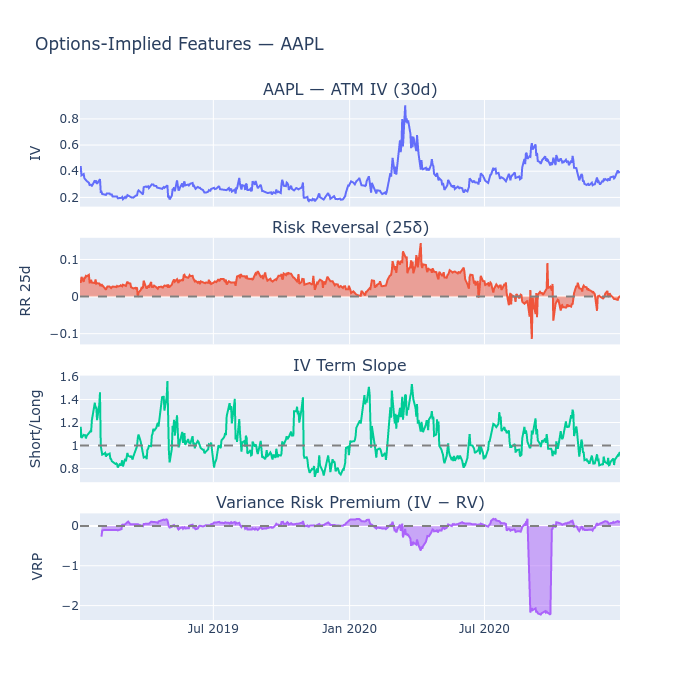

In [23]:
fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    subplot_titles=[
        f"{viz_symbol} — ATM IV (30d)",
        "Risk Reversal (25δ)",
        "IV Term Slope",
        "Variance Risk Premium (IV − RV)",
    ],
    vertical_spacing=0.06,
)

fig.add_trace(
    go.Scatter(x=viz["timestamp"].to_list(), y=viz["iv_atm_30"].to_list(), name="ATM IV"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=viz["timestamp"].to_list(),
        y=viz["risk_reversal_25d"].to_list(),
        name="RR 25δ",
        fill="tozeroy",
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=1)

fig.add_trace(
    go.Scatter(
        x=viz["timestamp"].to_list(),
        y=viz["iv_term_slope"].to_list(),
        name="Term Slope",
    ),
    row=3,
    col=1,
)
fig.add_hline(y=1, line_dash="dash", line_color="gray", row=3, col=1)
fig.add_trace(
    go.Scatter(
        x=viz["timestamp"].to_list(),
        y=viz["vrp"].to_list(),
        name="VRP",
        fill="tozeroy",
    ),
    row=4,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=4, col=1)

fig.update_layout(height=700, title=f"Options-Implied Features — {viz_symbol}", showlegend=False)
fig.update_yaxes(title_text="IV", row=1, col=1)
fig.update_yaxes(title_text="RR 25d", row=2, col=1)
fig.update_yaxes(title_text="Short/Long", row=3, col=1)
fig.update_yaxes(title_text="VRP", row=4, col=1)
fig.show()

**Interpretation**:
- ATM IV spikes during market stress (COVID crash, etc.) — a key state variable
- Positive risk reversal indicates elevated put demand (crash fear)
- Term slope > 1 = inverted term structure (near-term event risk)
- VRP > 0 is normal; extreme VRP signals attractive vol-selling opportunities

**OI-based features** (dealer gamma, positioning) are conceptually valuable
but require granular open interest data not available in this dataset. The
aggregate Greeks approach in `22_sp500_equities_option_analytics_features`
provides a workable proxy.

**Surface stability**: If the quote selection policy (delta convention,
interpolation method, maturity mapping) changes mid-backtest, all
options-derived features become contaminated. Version your construction
choices alongside the features.

---

# Summary

## Feature Families

| Family | Key Features | Data Required | Primary Role |
|--------|-------------|---------------|-------------|
| **Carry** | Roll yield, funding rate | Multi-tenor futures, perps | Signal |
| **Term Structure** | Slope, curvature | 3+ tenors | Signal/state |
| **Cross-Asset** | Beta, lead-lag, relative value | Multi-asset prices | Signal |
| **Options-Implied** | ATM IV, skew, VRP, term slope | Options chain | State |

## Implementation Rules

1. **Carry requires paired tenors**: Missing deferred contracts produce NaN carry
2. **Beta window matters**: 21d for fast regime, 63d for stable estimate
3. **Lead-lag can be spurious**: Validate that leads aren't staleness artifacts
4. **Options features need surface policy**: Version construction choices
5. **VRP is usually positive**: Negative VRP is extreme and informative

## Practical Takeaways

1. **Carry varies by asset class**: in the snapshot above, CL trades closer to
   backwardation while GC is closer to contango — consistent with the
   asset-specific drivers (supply tightness vs cost-of-carry) discussed in §8.3
2. **Residual momentum isolates idiosyncratic return**: subtracting
   $\beta_{t,a} r_{t,m}$ removes the market component from each ETF's return.
   Whether residual momentum has higher IC than raw momentum is evaluated in
   the `etfs` case study (Chapter 11+) — this notebook only demonstrates the
   construction
3. **Options-implied features are state, not signal**: use them to condition
   faster signals
4. **Surface stability is non-negotiable**: changing quote conventions
   mid-backtest invalidates all options features

## Next Notebooks

- `04_fundamentals_macro_calendar` — Fundamentals, macro, calendar encodings
- `case_studies/cme_futures` — Full 30-product futures pipeline
- `case_studies/sp500_equity_option_analytics` — Full equity + options pipeline
- `case_studies/sp500_options` — Options straddle strategy pipeline